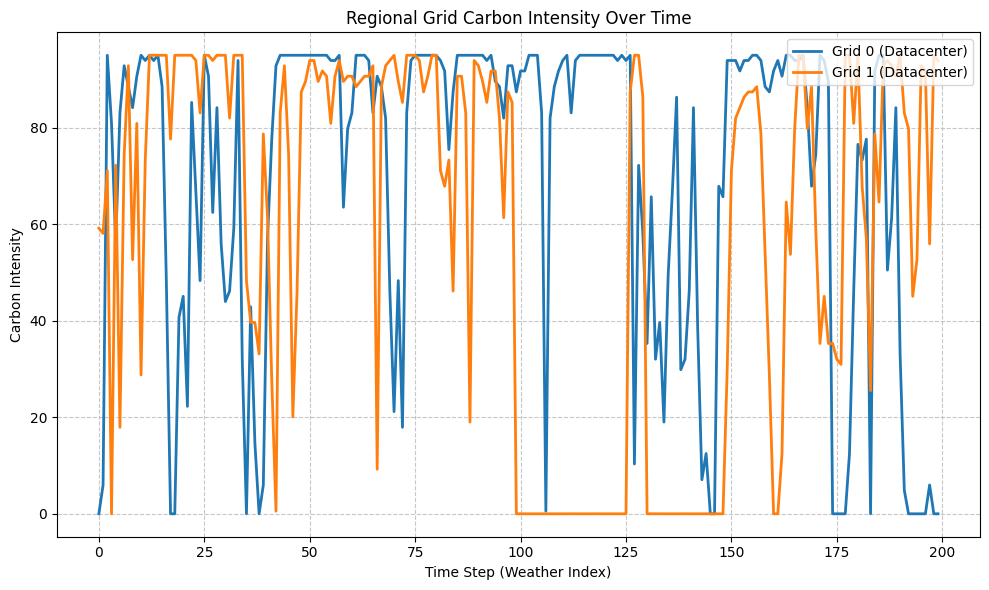

In [10]:
import pandapower.networks as pn
import matplotlib.pyplot as plt

from grid_custom import DatacenterGrid
from typing import List


_MAX_TIME_STEP: int = 200


class GridSimulation:
    """
    TODO: Add Docstring
    """

    def __init__(self, grids: List[DatacenterGrid]) -> None:
        """
        Constructs an instace of SimulationTwoGrid
        """
        self._grids = grids
        self._ci_data = [
            [] for _ in range(len(self._grids))
        ]
        self._ce_data = [
            [] for _ in range(len(self._grids))
        ]
        
        for grid in self._grids:
            status = grid.assign_new_data_center(
                load_id=0, idle_power=70.0
            )
            assert status
            status = grid.assign_renewable_source(
                gen_id=0, max_p_mw=80.0, gen_type="solar"
            )
            assert status
            grid.simplify_grid()

    def run(self) -> None:
        for step in range(_MAX_TIME_STEP):
            for idx, grid in enumerate(self._grids):
                grid.run_flow(weather_index=step)
                self._ci_data[idx].append(grid.get_grid_carbon_intensity())
        
    def plot_ci(self) -> None:
        """
        Plots the average carbon intensity over time for each data center grid.
        """
        # Safety check in case plot is called before run
        if not self._ci_data:
            print("No data to plot. Please call run() first.")
            return

        plt.figure(figsize=(10, 6))
        num_grids = len(self._ci_data)

        # Extract and plot the data for each grid separately
        for i in range(num_grids):
            grid_ci = self._ci_data[i]
            plt.plot(
                range(len(grid_ci)), 
                grid_ci, 
                label=f"Grid {i} (Datacenter)", 
                linewidth=2
            )

        # Formatting the chart for readability
        plt.title("Regional Grid Carbon Intensity Over Time")
        plt.xlabel("Time Step (Weather Index)")
        plt.ylabel("Carbon Intensity")
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.legend(loc="upper right")
        plt.tight_layout()
        
        # Display the plot
        plt.show()


grid_og = DatacenterGrid(net=pn.case30(), grid_region="CA_ON") # type: ignore
grid_target = DatacenterGrid(net=pn.case30(), grid_region="US_CAL_CISO") # type: ignore
sim = GridSimulation(grids=[grid_og, grid_target])
sim.run()
sim.plot_ci()


# Time period: 2020-08-01 ~ 2020-08-31
# 
# Todo:
#   1. Add background non-dc load and some generators (maybe)
#   2. Add interface to connect to the workload simulator 
#       - input for datacenter power load
#       - output for carbon emission rate (system average and datacenter specific) (and other grid metrics if needed ...)
#   3. Add flutuation of renewable generation (maybe based on weather data)
#       - weather data: /mnt/grid-cloud-migration-estimates_copy/data/weather (four regions CA_ON, US_CAL_CISO, US_MIDA_PJM, US_TEX_ERCO)
#   4. Try on a larger grid (e.g. IEEE 300-Bus System pandapower.networks.power_system_test_cases.case300)